# Day Ahead Energy Price Forecast

# ____________________ FÜR GOOGLE COLAB ____________________

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Change the current working directory to the 'master_colab' folder on Google Drive
os.chdir('/content/drive/MyDrive/master_colab')

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/master_colab


# ____________________ FÜR GOOGLE COLAB ____________________

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import tensorflow as tf
from tensorflow.keras import layers, callbacks
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import joblib
import pyarrow

import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
import gc

# Load Data

In [4]:
data = pd.read_parquet("entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("weather_forecast.parquet")
data = data.join(weather_fc, how="left")

# Feature Extraction

In [5]:
# lag features

## convert to local time to handle daylight saving time correctly
data = data.tz_convert("Europe/Berlin")

idx_naive = data.index.tz_localize(None)

prev_naive_day = idx_naive - pd.DateOffset(days = 1)
prev_naive_day2 = idx_naive - pd.DateOffset(days = 2)
prev_naive_week = idx_naive - pd.DateOffset(weeks = 1)

idx_prev_day = prev_naive_day.tz_localize(
    "Europe/Berlin",
    ambiguous= False,
    nonexistent="shift_forward",
)
idx_prev_day2 = prev_naive_day2.tz_localize(
    "Europe/Berlin",
    ambiguous= False,
    nonexistent="shift_forward",
)
idx_prev_week = prev_naive_week.tz_localize(
    "Europe/Berlin",
    ambiguous= False,
    nonexistent="shift_forward",
)


data["price_lag_24h"] = data["da_price"].reindex(idx_prev_day).to_numpy()
data["price_lag_48h"] = data["da_price"].reindex(idx_prev_day2).to_numpy()
data["price_lag_168h"] = data["da_price"].reindex(idx_prev_week).to_numpy()


# weekday
data["weekday_sin"] = np.sin(2 * np.pi * data.index.dayofweek / 7)  # cyclic, so that distances are correct (Sunday is close to Monday), same for hour
data["weekday_cos"] = np.cos(2 * np.pi * data.index.dayofweek / 7)

# hour of day
data["hour_sin"] = np.sin(2 * np.pi * data.index.hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * data.index.hour / 24)

# holiday not sunday
ger_holidays = list(holidays.Germany(years=data.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(data.index.tz)
data["holiday_not_sunday"] = (data.index.normalize().isin(ger_holidays) & (data.index.dayofweek != 6))


## back to utc
data = data.tz_convert("UTC")

# remove all data outside of 2023-2025 (only used for lag features)
data = data["2023":"2025"]

# Split Data

In [6]:
TRAIN_START = pd.Timestamp("2023-01-01", tz="UTC")
TRAIN_END = pd.Timestamp("2025-01-01", tz="UTC")
TEST_START = pd.Timestamp("2025-01-01", tz="UTC")
TEST_END = pd.Timestamp("2026-01-01", tz="UTC")

train_mask = (data.index >= TRAIN_START) & (data.index < TRAIN_END)
test_mask = (data.index >= TEST_START) & (data.index < TEST_END)

data_train = data.loc[train_mask].copy()
data_test = data.loc[test_mask].copy()


split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "start": [data_train.index.min(), data_test.index.min()],
    "end": [data_train.index.max(), data_test.index.max()],
    "rows": [len(data_train), len(data_test)],
})
split_summary

,split,start,end,rows
0,train,2023-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00,17544
1,test,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,8760


# Modelling Setup

In [7]:
# ---------- General setup ----------

LOOKBACK = 168
HORIZON_STEPS = 1
TARGET_COL = "da_price"

FEATURE_COLS = ['load_fc',
                "ssrd",
                "tcc",
                "t2m",
                "rh2m",
                "U100",
                "sp",
                'price_lag_24h',
                'price_lag_48h',
                'price_lag_168h',
                'weekday_sin',
                'weekday_cos',
                'hour_sin',
                'hour_cos',
                'holiday_not_sunday']

SCALE_COLS = [
    c for c in FEATURE_COLS
    if c in ["load_fc", "price_lag_24h", "price_lag_48h", "price_lag_168h", "ssrd", "tcc", "t2m", "rh2m", "U100", "sp"]
]


# build datasets
model_df = data[[TARGET_COL] + FEATURE_COLS].copy()
train_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < TRAIN_END)].copy()
test_df = model_df.loc[(model_df.index >= TEST_START) & (model_df.index < TEST_END)].copy()
test_history_df = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=LOOKBACK)) & (model_df.index < TEST_START)
].copy()
test_with_history_df = pd.concat([test_history_df, test_df], axis=0)


# helper functions for target transformation (for robustness against outliers)
c = np.median(np.abs(train_df[TARGET_COL]))
def asinh_transform(y, c):
    return np.arcsinh(y / c)
def asinh_inverse(y_t, c):
    return c * np.sinh(y_t)
# raw truth
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float32)


# Feature scaling (RobustScaler) + Target Transformation (asinh)
scaler = RobustScaler()
train_df.loc[:, SCALE_COLS] = scaler.fit_transform(train_df[SCALE_COLS])
train_df.loc[:, TARGET_COL] = asinh_transform(train_df[TARGET_COL], c)
test_df.loc[:, SCALE_COLS] = scaler.transform(test_df[SCALE_COLS])
test_df.loc[:, TARGET_COL] = asinh_transform(test_df[TARGET_COL], c)
test_history_df.loc[:, TARGET_COL] = asinh_transform(test_history_df[TARGET_COL].to_numpy(np.float32), c)
test_with_history_df = pd.concat([test_history_df, test_df], axis=0)
test_with_history_df.loc[test_df.index, SCALE_COLS] = test_df[SCALE_COLS]

# error functions for model performance evaluation
def mae_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))
def rmse_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)





# ---------- No-Lookback setup: ----------

def build_point_dataset(df: pd.DataFrame, feature_cols: list[str], target_col: str):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)
    ts = df.index
    return X, y, ts


X_train_point, y_train_point, ts_train_point = build_point_dataset(train_df, FEATURE_COLS, TARGET_COL)
X_test_point, y_test_point, ts_test_point = build_point_dataset(test_df, FEATURE_COLS, TARGET_COL)

display(pd.DataFrame([
    {"set": "point", "split": "train", "X": X_train_point.shape, "y": y_train_point.shape},
    {"set": "point", "split": "test", "X": X_test_point.shape, "y": y_test_point.shape},
]))




# ---------- Lookback setup ---------- :
# Fixed 168h window ending at D-1 23:00 for every target timestamp.
# All hours of the same day share the same price sequence.

SEQUENCE_COLS = [c for c in [TARGET_COL] if c in model_df.columns]


def build_lookback_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp (day D, hour h) the lookback window covers the
    168 hours ending at D-1 23:00.  All 24 hours of the same day therefore
    receive the identical price sequence; only the exog features differ.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values     = df[exog_cols].to_numpy(dtype=np.float32)
    target_values   = df[target_col].to_numpy(dtype=np.float32)
    hours           = np.array([ts.hour for ts in idx], dtype=np.int32)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(lookback_hours, len(df)):
        h        = hours[row_idx]
        # D-1 23:00 is (h+1) hours before ts  →  row_idx - (h+1) in the index
        keep_idx = np.arange(row_idx - h - lookback_hours, row_idx - h)
        if keep_idx[0] < 0:
            continue
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )


# --- build datasets ---
X_train_seq_lookback, X_train_exog_lookback, y_train_lookback, ts_train_lookback = build_lookback_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_test_seq_lookback, X_test_exog_lookback, y_test_lookback, ts_test_lookback = build_lookback_dataset(
    test_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)
test_keep_mask       = ts_test_lookback >= TEST_START
X_test_seq_lookback  = X_test_seq_lookback[test_keep_mask]
X_test_exog_lookback = X_test_exog_lookback[test_keep_mask]
y_test_lookback      = y_test_lookback[test_keep_mask]
ts_test_lookback     = ts_test_lookback[test_keep_mask]

# flat layout for XGBoost
X_train_flat_lookback = np.concatenate([
    X_train_seq_lookback.reshape(X_train_seq_lookback.shape[0], -1),
    X_train_exog_lookback,
], axis=1)
X_test_flat_lookback = np.concatenate([
    X_test_seq_lookback.reshape(X_test_seq_lookback.shape[0], -1),
    X_test_exog_lookback,
], axis=1)

display(pd.DataFrame([
    {"split": "train", "X_seq": X_train_seq_lookback.shape, "X_exog": X_train_exog_lookback.shape, "X_flat": X_train_flat_lookback.shape, "y": y_train_lookback.shape},
    {"split": "test",  "X_seq": X_test_seq_lookback.shape,  "X_exog": X_test_exog_lookback.shape,  "X_flat": X_test_flat_lookback.shape,  "y": y_test_lookback.shape},
]))

,set,split,X,y
0,point,train,"(17544, 15)","(17544,)"
1,point,test,"(8760, 15)","(8760,)"


,split,X_seq,X_exog,X_flat,y
0,train,"(17376, 168, 1)","(17376, 15)","(17376, 183)","(17376,)"
1,test,"(8760, 168, 1)","(8760, 15)","(8760, 183)","(8760,)"


### No-Lookback Setup

# Feature Selection

### Feature Exploration

In [ ]:
feature_eval = pd.DataFrame(index=FEATURE_COLS)
feature_eval["missing_ratio"] = train_df[FEATURE_COLS].isna().mean()
feature_eval["corr_with_asinh(price)"] = [train_df["da_price"].corr(train_df[c]) for c in FEATURE_COLS]

clean_for_mi = train_df[["da_price"] + FEATURE_COLS].copy()
X_mi = clean_for_mi[FEATURE_COLS].copy()
X_mi["holiday_not_sunday"] = X_mi["holiday_not_sunday"].astype(int)
mi = mutual_info_regression(X_mi, clean_for_mi["da_price"], random_state=1904)
feature_eval["mutual_info"] = mi

feature_eval.loc["hour_combined", "missing_ratio"] = feature_eval.loc[["hour_sin", "hour_cos"], "missing_ratio"].max()
feature_eval.loc["hour_combined", "corr_with_asinh(price)"] = np.sqrt(
    feature_eval.loc["hour_sin", "corr_with_asinh(price)"] ** 2 + feature_eval.loc["hour_cos", "corr_with_asinh(price)"] ** 2
)
feature_eval.loc["hour_combined", "mutual_info"] = np.nan

feature_eval.loc["weekday_combined", "missing_ratio"] = feature_eval.loc[["weekday_sin", "weekday_cos"], "missing_ratio"].max()
feature_eval.loc["weekday_combined", "corr_with_asinh(price)"] = np.sqrt(
    feature_eval.loc["weekday_sin", "corr_with_asinh(price)"] ** 2 + feature_eval.loc["weekday_cos", "corr_with_asinh(price)"] ** 2
)
feature_eval.loc["weekday_combined", "mutual_info"] = np.nan

for y in [2023, 2024]:
    y_mask = train_df.index.year == y
    year_corr = pd.Series({
        c: train_df.loc[y_mask, "da_price"].corr(train_df.loc[y_mask, c]) for c in FEATURE_COLS
    })
    feature_eval[f"corr_{y}"] = year_corr
    feature_eval.loc["hour_combined", f"corr_{y}"] = np.sqrt(
        feature_eval.loc["hour_sin", f"corr_{y}"] ** 2 + feature_eval.loc["hour_cos", f"corr_{y}"] ** 2
    )
    feature_eval.loc["weekday_combined", f"corr_{y}"] = np.sqrt(
        feature_eval.loc["weekday_sin", f"corr_{y}"] ** 2 + feature_eval.loc["weekday_cos", f"corr_{y}"] ** 2
    )


corr_cols = ["corr_2023", "corr_2024"]
feature_eval["corr_std_across_years"] = feature_eval[corr_cols].std(axis=1)
display(feature_eval)

,missing_ratio,corr_with_asinh(price),mutual_info,corr_2023,corr_2024,corr_std_across_years
load_fc,0.0000,0.2793,0.1275,0.3396,0.2285,0.0786
ssrd,0.0000,-0.2287,0.0779,-0.1758,-0.2911,0.0815
tcc,0.0000,-0.0864,0.0232,-0.0708,-0.1122,0.0293
t2m,0.0000,-0.2233,0.1038,-0.2382,-0.2101,0.0199
rh2m,0.0000,0.2283,0.0751,0.2039,0.3055,0.0718
U100,0.0000,-0.4475,0.1573,-0.5056,-0.4206,0.0601
sp,0.0000,0.2481,0.0975,0.2668,0.2457,0.0149
price_lag_24h,0.0000,0.6327,0.4183,0.6266,0.6185,0.0057
price_lag_48h,0.0000,0.4529,0.2236,0.4381,0.4359,0.0015
price_lag_168h,0.0000,0.4926,0.2732,0.4751,0.4776,0.0018


### Feature Importance Rankings


── Feature Selection Ranking ──
                    xgb_gain  lasso_abs_coef
load_fc               0.1090          0.9880
ssrd                  0.1170          0.3680
tcc                   0.0000          0.0000
t2m                   0.0520          0.0000
rh2m                  0.0130          0.0470
U100                  0.2950          1.0000
sp                    0.0070          0.0000
price_lag_24h         1.0000          0.4300
price_lag_48h         0.0230          0.1090
price_lag_168h        0.1890          0.3310
holiday_not_sunday    0.4050          0.0000
hour                  0.1190          0.3950
weekday               0.1850          0.0860


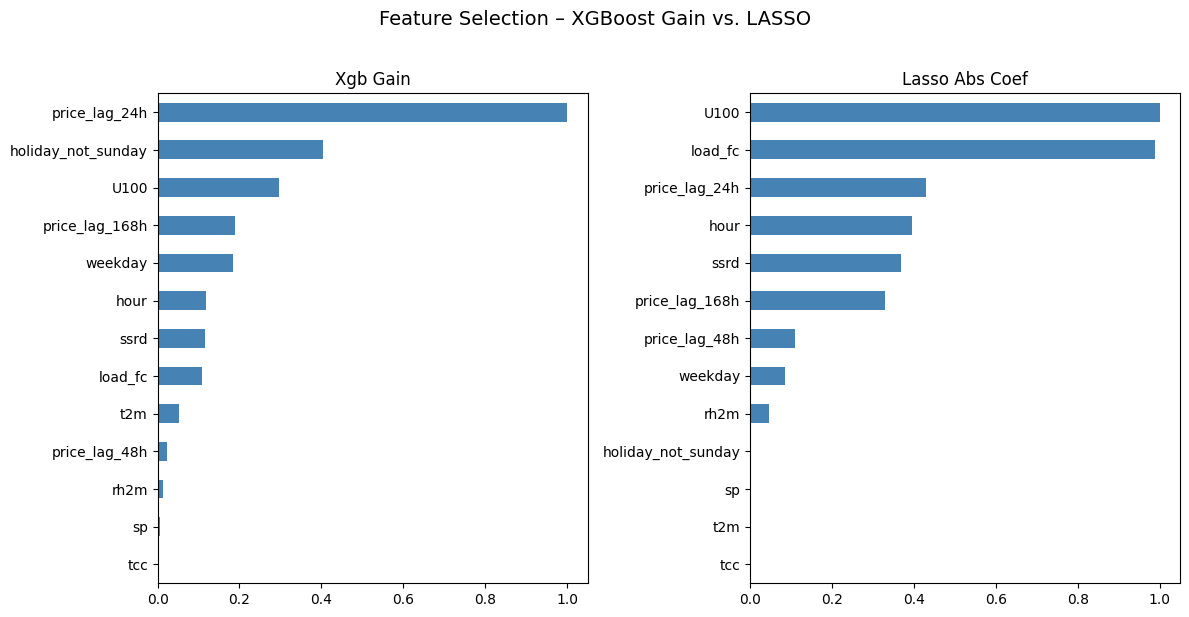

In [ ]:
# ── Feature Selection: Embedded & Wrapper Methods ──────────────────────────
from sklearn.linear_model import LassoCV
from xgboost import XGBRegressor

# ── Zyklische Feature-Gruppen ──
cyclic_pairs = {
    "hour":    ["hour_sin", "hour_cos"],
    "weekday": ["weekday_sin", "weekday_cos"],
}
single_features = [f for f in FEATURE_COLS if not any(f in pair for pair in cyclic_pairs.values())]
display_names = single_features + list(cyclic_pairs.keys())

col_idx = {f: i for i, f in enumerate(FEATURE_COLS)}


# ── 1) XGBoost Feature Importance (gain) ──
xgb_fs = XGBRegressor(random_state=1904, n_jobs=-1)
xgb_fs.fit(X_train_point, y_train_point)

raw_xgb = pd.Series(xgb_fs.feature_importances_, index=FEATURE_COLS)
xgb_importance = pd.Series(dtype=float, name="xgb_gain")
for f in single_features:
    xgb_importance[f] = raw_xgb[f]
for name, cols in cyclic_pairs.items():
    xgb_importance[name] = np.sqrt((raw_xgb[cols] ** 2).sum())


# ── 2) LASSO (L1-Regularisierung) ──
lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=1904, n_jobs=-1)
lasso.fit(X_train_point, y_train_point)

raw_lasso = pd.Series(np.abs(lasso.coef_), index=FEATURE_COLS)
lasso_coefs = pd.Series(dtype=float, name="lasso_abs_coef")
for f in single_features:
    lasso_coefs[f] = raw_lasso[f]
for name, cols in cyclic_pairs.items():
    lasso_coefs[name] = np.sqrt((raw_lasso[cols] ** 2).sum())


# ── Ranking ──────────────────────────────────────────────────
fs_results = pd.DataFrame({
    "xgb_gain":       xgb_importance,
    "lasso_abs_coef": lasso_coefs,
}, index=display_names)

fs_norm = fs_results.apply(lambda col: (col - col.min()) / (col.max() - col.min()))

print("\n── Feature Selection Ranking ──")
print(fs_norm.round(3).to_string())

# ── Visualisierung ──
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, col in zip(axes, fs_norm.columns):
    fs_norm[col].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlim(0, 1.05)
axes[0].set_ylabel("")
fig.suptitle("Feature Selection – XGBoost Gain vs. LASSO", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Recursive Feature Elimination


Config: default — sklearn defaults
Alle 13 Features → CV-MAE: 0.1541
  Bester Kandidat: 't2m' → CV-MAE: 0.1519  (Δ = -0.0022)
    → Entfernt. Verbleibend: ['load_fc', 'ssrd', 'tcc', 'rh2m', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Bester Kandidat: 'sp' → CV-MAE: 0.1506  (Δ = -0.0013)
    → Entfernt. Verbleibend: ['load_fc', 'ssrd', 'tcc', 'rh2m', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Bester Kandidat: 'tcc' → CV-MAE: 0.1499  (Δ = -0.0006)
    → Entfernt. Verbleibend: ['load_fc', 'ssrd', 'rh2m', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Bester Kandidat: 'holiday_not_sunday' → CV-MAE: 0.1506  (Δ = +0.0006)
    → Entfernt. Verbleibend: ['load_fc', 'ssrd', 'rh2m', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'hour', 'weekday']
  Bester Kandidat: 'rh2m' → CV-MAE: 0.1509  (Δ = +0.0003)


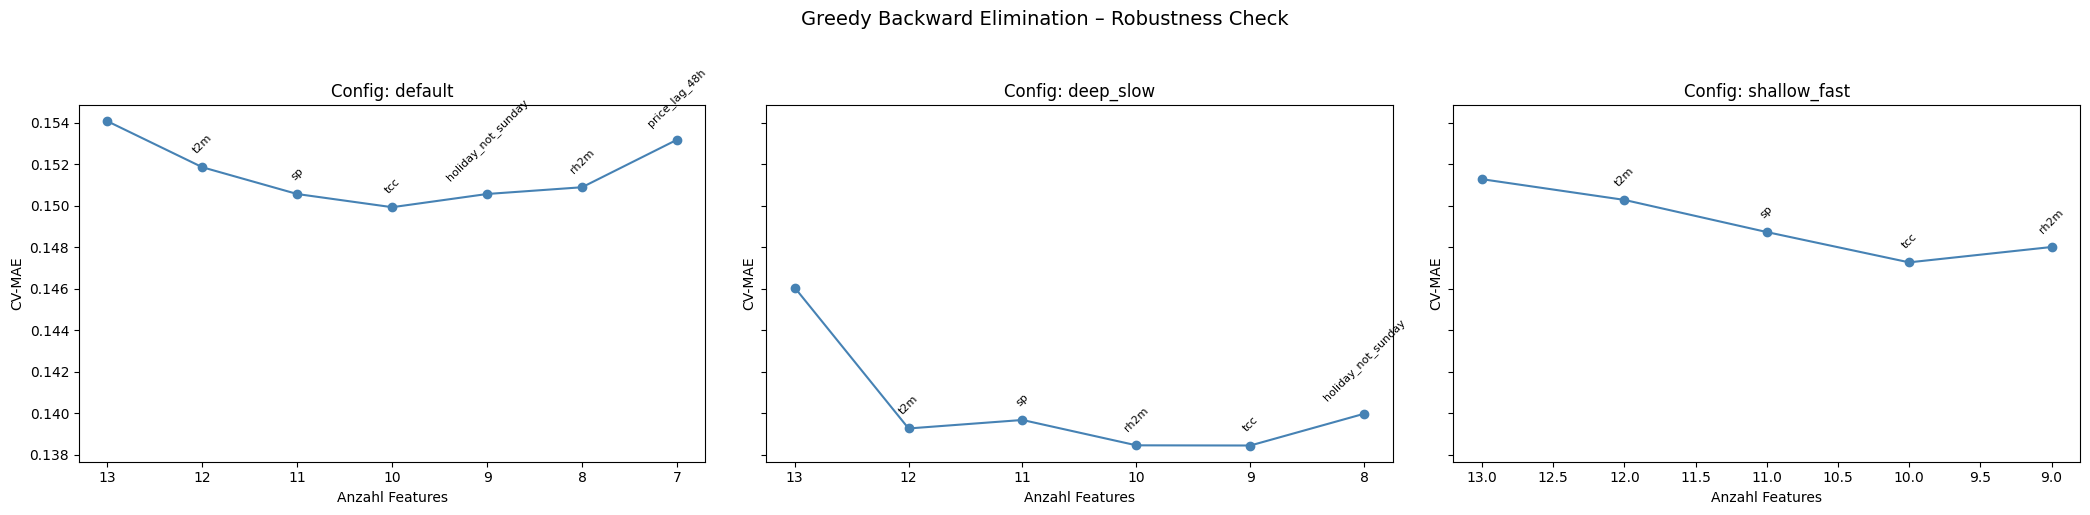

In [ ]:
# ── Greedy Backward Elimination mit CV (Multi-Config) ──────────────────────
from sklearn.model_selection import cross_val_score
from collections import Counter

tscv = TimeSeriesSplit(n_splits=5)

def get_col_indices(selected_names):
    indices = []
    for name in selected_names:
        if name in cyclic_pairs:
            indices += [col_idx[c] for c in cyclic_pairs[name]]
        else:
            indices.append(col_idx[name])
    return indices

configs = [
    {"label": "default",      "params": {}},
    {"label": "deep_slow",    "params": {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}},
    {"label": "shallow_fast", "params": {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.1}},
]

all_results = {}

for cfg in configs:
    label = cfg["label"]
    print(f"\n{'='*60}")
    print(f"Config: {label} — {cfg['params'] or 'sklearn defaults'}")
    print(f"{'='*60}")

    def cv_mae_for_features(selected_names):
        idx = get_col_indices(selected_names)
        return -cross_val_score(
            XGBRegressor(
                objective="reg:squarederror", random_state=1904, n_jobs=-1,
                **cfg["params"],
            ),
            X_train_point[:, idx], y_train_point,
            cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1,
        ).mean()

    remaining = display_names.copy()
    current_score = cv_mae_for_features(remaining)
    elimination_log = [{"n_features": len(remaining), "removed": None, "cv_mae": current_score}]
    print(f"Alle {len(remaining)} Features → CV-MAE: {current_score:.4f}")

    while len(remaining) > 1:
        trials = []
        for candidate in remaining:
            trial = [f for f in remaining if f != candidate]
            score = cv_mae_for_features(trial)
            trials.append((candidate, score, trial))

        best_candidate, best_score, best_trial = min(trials, key=lambda x: x[1])
        elimination_log.append({"n_features": len(best_trial), "removed": best_candidate, "cv_mae": best_score})

        print(f"  Bester Kandidat: '{best_candidate}' → CV-MAE: {best_score:.4f}  (Δ = {best_score - current_score:+.4f})")

        if best_score <= current_score * 1.005:
            remaining = best_trial
            current_score = best_score
            print(f"    → Entfernt. Verbleibend: {remaining}")
        else:
            print(f"    → Keine Verbesserung. Stopp.")
            break

    all_results[label] = {
        "remaining": remaining,
        "log": pd.DataFrame(elimination_log),
    }
    print(f"Finale Features ({len(remaining)}): {remaining}")


# ── Übersicht: wie oft wurde jedes Feature entfernt? ──

removed_counts = Counter()
for label, result in all_results.items():
    removed_in_config = set(display_names) - set(result["remaining"])
    removed_counts.update(removed_in_config)

print(f"\n{'='*60}")
for f in display_names:
    count = removed_counts.get(f, 0)
    if count > 0:
        print(f"  {f}: entfernt in {count}/{len(configs)} Configs")
print(f"{'='*60}")



# ── Visualisierung ──
fig, axes = plt.subplots(1, len(configs), figsize=(7 * len(configs), 5), sharey=True)
for ax, (label, result) in zip(axes, all_results.items()):
    log_df = result["log"]
    ax.plot(log_df["n_features"], log_df["cv_mae"], "o-", color="steelblue")
    for _, row in log_df.iterrows():
        if row["removed"]:
            ax.annotate(row["removed"], (row["n_features"], row["cv_mae"]),
                        textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center", rotation=45)
    ax.set_xlabel("Anzahl Features")
    ax.set_ylabel("CV-MAE")
    ax.set_title(f"Config: {label}")
    ax.invert_xaxis()
fig.suptitle("Greedy Backward Elimination – Robustness Check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


The weather features *t2m*, *sp*, *tcc* and *rh2m* have a lack of importance to the basic models. Only the weather features *U100* and *ssrd* will be kept for the modeling and work as proxies for the wind generation (*U100*) and solar generation (*ssrd*).

### Delete Features

In [8]:
# ── Gewählte Variablen aus bestehenden Objekten entfernen ───────────────────
DROP_COLS = ["t2m", "sp", "tcc", "rh2m"]

# Alte Reihenfolge merken, weil die bestehenden Arrays noch darauf basieren
old_feature_cols = FEATURE_COLS.copy()

# Behaltene Features + zugehörige Indizes
keep_cols = [c for c in old_feature_cols if c not in DROP_COLS]
keep_idx = [old_feature_cols.index(c) for c in keep_cols]

# Listen aktualisieren
FEATURE_COLS = keep_cols
SCALE_COLS = [c for c in SCALE_COLS if c not in DROP_COLS]

# DataFrames aktualisieren
model_df = model_df.drop(columns=DROP_COLS)
train_df = train_df.drop(columns=DROP_COLS)
test_df = test_df.drop(columns=DROP_COLS)
test_history_df = test_history_df.drop(columns=DROP_COLS)
test_with_history_df = test_with_history_df.drop(columns=DROP_COLS)

# Point-Datasets aktualisieren
X_train_point = X_train_point[:, keep_idx]
X_test_point = X_test_point[:, keep_idx]

# Lookback-Exog-Datasets aktualisieren
X_train_exog_lookback = X_train_exog_lookback[:, keep_idx]
X_test_exog_lookback = X_test_exog_lookback[:, keep_idx]

# Flat-Lookback-Datasets neu zusammensetzen
X_train_flat_lookback = np.concatenate([
    X_train_seq_lookback.reshape(X_train_seq_lookback.shape[0], -1),
    X_train_exog_lookback,
], axis=1)

X_test_flat_lookback = np.concatenate([
    X_test_seq_lookback.reshape(X_test_seq_lookback.shape[0], -1),
    X_test_exog_lookback,
], axis=1)


display(pd.DataFrame([
    {"split": "train", "X_seq": X_train_seq_lookback.shape, "X_exog": X_train_exog_lookback.shape, "X_flat": X_train_flat_lookback.shape, "y": y_train_lookback.shape},
    {"split": "test",  "X_seq": X_test_seq_lookback.shape,  "X_exog": X_test_exog_lookback.shape,  "X_flat": X_test_flat_lookback.shape,  "y": y_test_lookback.shape},
]))


,split,X_seq,X_exog,X_flat,y
0,train,"(17376, 168, 1)","(17376, 11)","(17376, 179)","(17376,)"
1,test,"(8760, 168, 1)","(8760, 11)","(8760, 179)","(8760,)"


# SARIMAX diagnostic to find hyperparameters

In [ ]:
from statsmodels.tsa.stattools import adfuller

for label, series in [("Original", endog), ("Sais. diff.", endog_diff)]:
    adf_stat, p_val, *_ = adfuller(series.dropna())
    print(f"{label:15s}  ADF={adf_stat:.3f}  p={p_val:.4f}  {'stationär ✓' if p_val < 0.05 else 'nicht stationär ✗'}")


Original         ADF=-10.942  p=0.0000  stationär ✓
Sais. diff.      ADF=-26.552  p=0.0000  stationär ✓


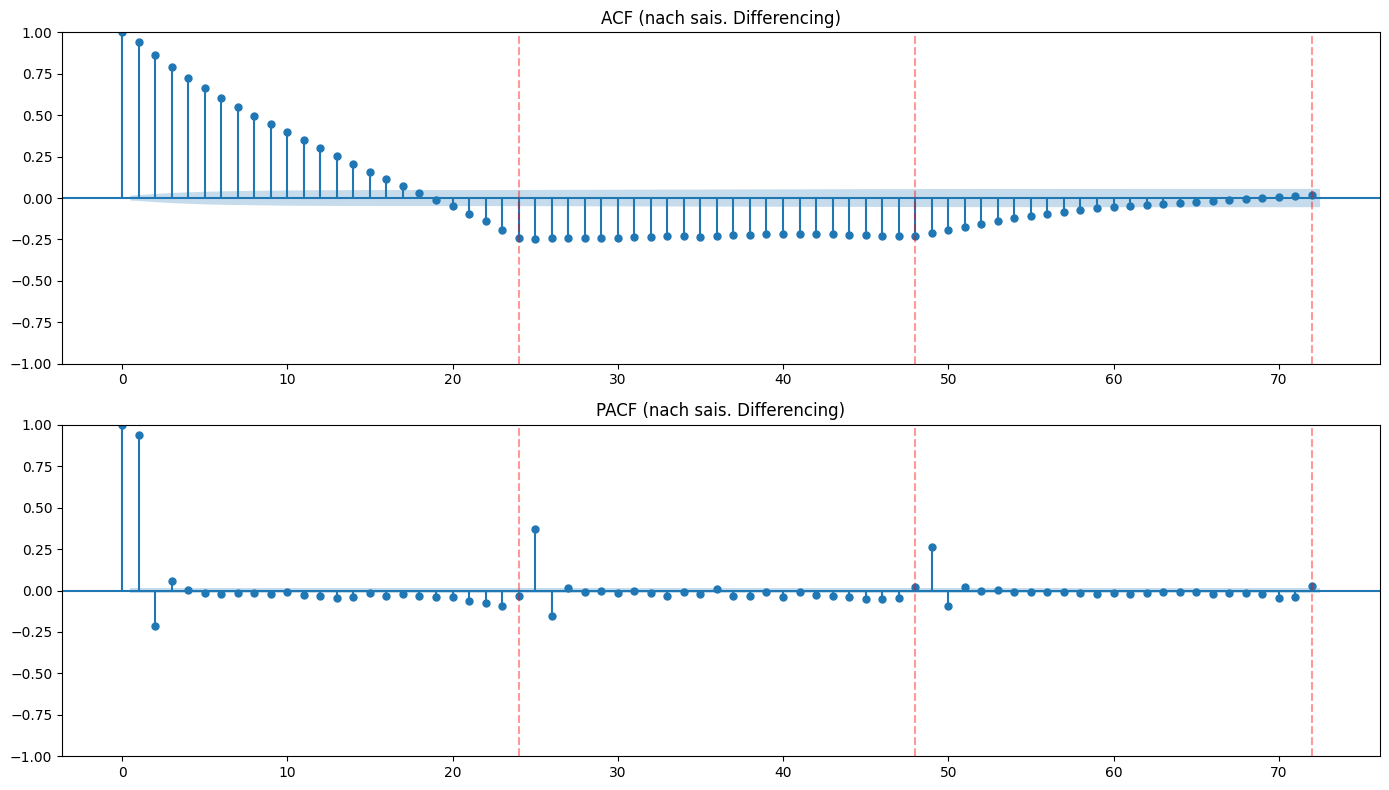

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Auf saisonal-differenzierter Reihe plotten (so wie SARIMAX sie sieht)
endog = train_df[TARGET_COL].astype(np.float64)
endog_diff = endog.diff(24).dropna()  # D=1, s=24

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(endog_diff,  lags=72, ax=axes[0], title="ACF (nach sais. Differencing)")
plot_pacf(endog_diff, lags=72, ax=axes[1], title="PACF (nach sais. Differencing)")

# Vertikale Markierungen bei saisonalen Lags
for ax in axes:
    for lag in [24, 48, 72]:
        ax.axvline(x=lag, color="red", linestyle="--", alpha=0.4, label=f"Lag {lag}")

plt.tight_layout()
plt.show()


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_2088/552720064.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(x, regression="c", nlags="auto")[1]
/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_2088/552720064.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(x, regression="c", nlags="auto")[1]
/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_2088/552720064.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(x, regression="c", nlags="auto")[1]
/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_2088/552720064.py:17: InterpolationWarnin

,series,n,adf_p,kpss_p,is_stationary
0,y,17544,0.0000,0.0100,False
1,diff_1,17543,0.0000,0.1000,True
2,diff_s,17520,0.0000,0.1000,True
3,diff_1_s,17519,0.0000,0.1000,True


Recommended differencing: d=0, D=1, s=24
Order hints -> p in [0, 1, 2], q in [0, 1, 2], P in [0, 1], Q in [0, 1]
Reduced search_space size: 16
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 1, 0), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 2, 0, 0), (0, 2, 1, 0), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (2, 0, 0, 0), (2, 0, 0, 1)]


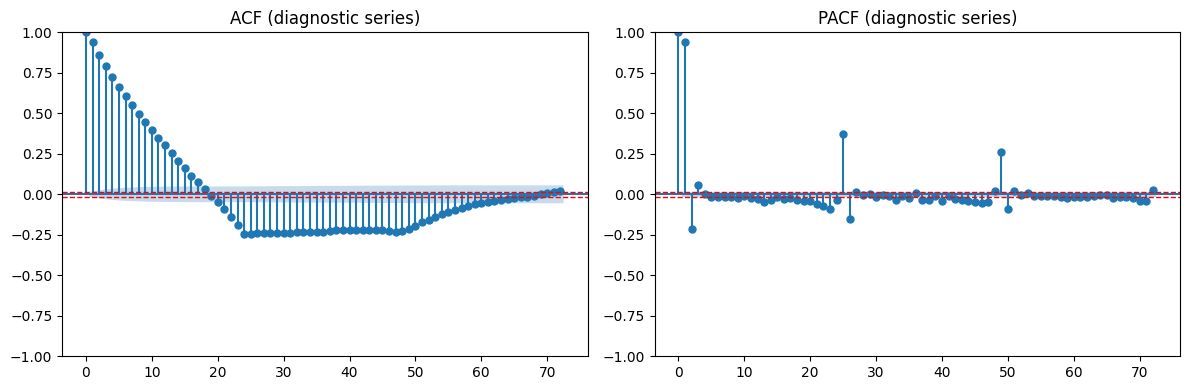

In [ ]:
# SARIMAX diagnostics before modelling
from itertools import product
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

S = 24
diag_y = train_df[TARGET_COL].astype(float).dropna()

def stationarity_tests(x):
    adf_p = np.nan
    kpss_p = np.nan
    try:
        adf_p = adfuller(x, autolag="AIC")[1]
    except Exception:
        pass
    try:
        kpss_p = kpss(x, regression="c", nlags="auto")[1]
    except Exception:
        pass
    is_stationary = (np.isfinite(adf_p) and adf_p < 0.05) and (not np.isfinite(kpss_p) or kpss_p > 0.05)
    return {"adf_p": adf_p, "kpss_p": kpss_p, "is_stationary": is_stationary}

series_dict = {
    "y": diag_y,
    "diff_1": diag_y.diff().dropna(),
    "diff_s": diag_y.diff(S).dropna(),
    "diff_1_s": diag_y.diff().diff(S).dropna(),
}

diag_rows = []
for name, s in series_dict.items():
    t = stationarity_tests(s.values)
    diag_rows.append({"series": name, "n": len(s), **t})
diag_df = pd.DataFrame(diag_rows)
display(diag_df)

if bool(diag_df.loc[diag_df["series"] == "y", "is_stationary"].iloc[0]):
    rec_d, rec_D = 0, 0
elif bool(diag_df.loc[diag_df["series"] == "diff_s", "is_stationary"].iloc[0]):
    rec_d, rec_D = 0, 1
elif bool(diag_df.loc[diag_df["series"] == "diff_1", "is_stationary"].iloc[0]):
    rec_d, rec_D = 1, 0
else:
    rec_d, rec_D = 1, 1

print(f"Recommended differencing: d={rec_d}, D={rec_D}, s={S}")

if rec_d == 1 and rec_D == 1:
    y_for_orders = diag_y.diff().diff(S).dropna()
elif rec_d == 1:
    y_for_orders = diag_y.diff().dropna()
elif rec_D == 1:
    y_for_orders = diag_y.diff(S).dropna()
else:
    y_for_orders = diag_y.copy()

max_lag = min(72, max(24, len(y_for_orders) // 10))
n = len(y_for_orders)
conf = 1.96 / np.sqrt(n)

acf_vals = acf(y_for_orders, nlags=max_lag, fft=True)
pacf_vals = pacf(y_for_orders, nlags=max_lag, method="ywmle")

sig_acf = [lag for lag in range(1, min(4, len(acf_vals))) if abs(acf_vals[lag]) > conf]
sig_pacf = [lag for lag in range(1, min(4, len(pacf_vals))) if abs(pacf_vals[lag]) > conf]
sig_acf_s = abs(acf_vals[S]) > conf if len(acf_vals) > S else False
sig_pacf_s = abs(pacf_vals[S]) > conf if len(pacf_vals) > S else False

p_max = min(2, max([0] + sig_pacf))
q_max = min(2, max([0] + sig_acf))
P_max = 1 if sig_pacf_s else 0
Q_max = 1 if sig_acf_s else 0

p_vals = list(range(0, p_max + 1))
q_vals = list(range(0, q_max + 1))
P_vals = list(range(0, P_max + 1))
Q_vals = list(range(0, Q_max + 1))

if p_vals == [0]:
    p_vals = [0, 1]
if q_vals == [0]:
    q_vals = [0, 1]
if P_vals == [0]:
    P_vals = [0, 1]
if Q_vals == [0]:
    Q_vals = [0, 1]

search_space = [
    (p, q, P, Q)
    for p, q, P, Q in product(p_vals, q_vals, P_vals, Q_vals)
    if (p + q) <= 2 and (P + Q) <= 1 and not ((p >= 2 and P >= 1) or (q >= 2 and Q >= 1))
]
search_space = sorted(set(search_space))

print(f"Order hints -> p in {p_vals}, q in {q_vals}, P in {P_vals}, Q in {Q_vals}")
print(f"Reduced search_space size: {len(search_space)}")
print(search_space)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_for_orders, lags=min(72, max_lag), ax=axes[0])
axes[0].axhline(conf, color="red", linestyle="--", linewidth=1)
axes[0].axhline(-conf, color="red", linestyle="--", linewidth=1)
axes[0].set_title("ACF (diagnostic series)")

plot_pacf(y_for_orders, lags=min(72, max_lag), ax=axes[1], method="ywmle")
axes[1].axhline(conf, color="red", linestyle="--", linewidth=1)
axes[1].axhline(-conf, color="red", linestyle="--", linewidth=1)
axes[1].set_title("PACF (diagnostic series)")

plt.tight_layout()
plt.show()


# **************** MODELLING ****************

## ____________________ XGBoost ____________________




In [ ]:
xgb_base = dict(
    objective="reg:squarederror",
    random_state=1904,
    n_jobs=-1,
    device="cuda"
)

param_dist = {
    "n_estimators": [100, 200, 400, 500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "min_child_weight": [1, 3, 5, 7],
}

In [ ]:
# Point-Model tuning
tscv_point = TimeSeriesSplit(n_splits=5)

search_point = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_point,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_point.fit(X_train_point, y_train_point)
xgb_point = search_point.best_estimator_
y_pred_xgb_point = asinh_inverse(xgb_point.predict(X_test_point), c)

print("Best params (point):", search_point.best_params_)
print("Best CV score (point):", -search_point.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [12:36:52] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params (point): {'subsample': 0.6, 'reg_lambda': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV score (point): 0.13566648364067077


In [ ]:
# Lookback-Model tuning
tscv_lookback = TimeSeriesSplit(n_splits=5)

search_lookback = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_lookback,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_lookback.fit(X_train_flat_lookback, y_train_lookback)
xgb_lookback = search_lookback.best_estimator_

y_pred_xgb_lookback = asinh_inverse(
    xgb_lookback.predict(X_test_flat_lookback).astype(np.float32), c
)

print("Best params (lookback):", search_lookback.best_params_)
print("Best CV score (lookback):", -search_lookback.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (lookback): {'subsample': 0.8, 'reg_lambda': 2.0, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
Best CV score (lookback): 0.13206894993782042


In [ ]:
# save models
joblib.dump(xgb_point, "xgb_point_model.joblib")
joblib.dump(xgb_lookback, "xgb_lookback_model.joblib")


['xgb_lookback_model.joblib']

In [ ]:
# load models
xgb_point = joblib.load("xgb_point_model.joblib")
xgb_lookback = joblib.load("xgb_lookback_model.joblib")

In [ ]:
y_pred_xgb_point_t = xgb_point.predict(X_test_point)
y_pred_xgb_point   = asinh_inverse(y_pred_xgb_point_t, c)

y_pred_xgb_lookback_t = xgb_lookback.predict(X_test_flat_lookback)
y_pred_xgb_lookback   = asinh_inverse(y_pred_xgb_lookback_t, c)

scores = pd.DataFrame([
    {"model": "xgb_point",    "mae": mae_score(y_test, y_pred_xgb_point),    "rmse": rmse_score(y_test, y_pred_xgb_point)},
    {"model": "xgb_lookback", "mae": mae_score(y_test, y_pred_xgb_lookback), "rmse": rmse_score(y_test, y_pred_xgb_lookback)},
]).sort_values("mae")

scores

,model,mae,rmse
1,xgb_lookback,15.3504,24.7888
0,xgb_point,16.2255,25.6242


## ____________________ Random Forest ____________________


In [ ]:
from cuml.ensemble import RandomForestRegressor as RFRegressor

rf_base = dict(random_state=1904)

rf_param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [8, 12, 16, 20, 32],   # no None: cuML requires int
    "max_features":      [0.33, 0.5, "sqrt"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_samples":       [0.6, 0.8, 1.0],        # bootstrap fraction
}

In [ ]:
# Point-Model tuning
tscv_rf_point = TimeSeriesSplit(n_splits=5)

search_rf_point = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_rf_point,
    verbose=1,
    random_state=1904,
    n_jobs=1
)

search_rf_point.fit(X_train_point, y_train_point)
rf_point = search_rf_point.best_estimator_

print("Best params (RF point):", search_rf_point.best_params_)
print("Best CV MAE  (RF point):", -search_rf_point.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF point): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 1.0, 'max_features': 0.33, 'max_depth': 16}
Best CV MAE  (RF point): 0.14088583886623382


In [ ]:
# Lookback-Model tuning
tscv_rf_lookback = TimeSeriesSplit(n_splits=5)

search_rf_lookback = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_rf_lookback,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_lookback.fit(X_train_flat_lookback, y_train_lookback)
rf_lookback = search_rf_lookback.best_estimator_

print("Best params (RF lookback):", search_rf_lookback.best_params_)
print("Best CV MAE  (RF lookback):", -search_rf_lookback.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF lookback): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20}
Best CV MAE  (RF lookback): 0.13954610824584962


In [ ]:
# save models
joblib.dump(rf_point,    "rf_point_model.joblib")
joblib.dump(rf_lookback, "rf_lookback_model.joblib")

['rf_lookback_model.joblib']

In [ ]:
# load models
rf_point = joblib.load("rf_point_model.joblib")
rf_lookback = joblib.load("rf_lookback_model.joblib")

In [ ]:
y_pred_rf_point_t    = rf_point.predict(X_test_point)
y_pred_rf_point      = asinh_inverse(y_pred_rf_point_t, c)

y_pred_rf_lookback_t = rf_lookback.predict(X_test_flat_lookback)
y_pred_rf_lookback   = asinh_inverse(y_pred_rf_lookback_t.astype(np.float32), c)

# Create a DataFrame for RF scores
rf_scores = pd.DataFrame([
    {"model": "rf_point",    "mae": mae_score(y_test, y_pred_rf_point),    "rmse": rmse_score(y_test, y_pred_rf_point)},
    {"model": "rf_lookback", "mae": mae_score(y_test, y_pred_rf_lookback), "rmse": rmse_score(y_test, y_pred_rf_lookback)},
])

# Concatenate with the existing scores and sort by MAE
scores = pd.concat([scores, rf_scores]).sort_values("mae")
display(scores)

,model,mae,rmse
1,xgb_lookback,15.3504,24.7888
1,rf_lookback,16.1836,26.2086
0,xgb_point,16.2255,25.6242
0,rf_point,16.3025,25.8257


## ____________________ SVM ____________________


In [ ]:
from cuml.svm import SVR as SVRModel

svm_param_dist = {
    "C":       [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.05, 0.1, 0.5, 1.0],
    "gamma":   ["scale", "auto", 0.001, 0.01, 0.1],  # only rbf-kernel because of cuML
}

In [ ]:
# Point-Model tuning
tscv_svm_point = TimeSeriesSplit(n_splits=5)

search_svm_point = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_svm_point,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)
search_svm_point.fit(X_train_point, y_train_point)

svm_point = search_svm_point.best_estimator_

print("Best params (RF lookback):", search_svm_point.best_params_)
print("Best CV MAE  (RF lookback):", -search_svm_point.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF lookback): {'gamma': 'auto', 'epsilon': 0.05, 'C': 1}
Best CV MAE  (RF lookback): 0.14328912496566773


In [ ]:
tscv_svm_lookback = TimeSeriesSplit(n_splits=5)

search_svm_lookback = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_svm_lookback,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_lookback.fit(X_train_flat_lookback, y_train_lookback)
svm_lookback = search_svm_lookback.best_estimator_

print("Best params (SVM lookback):", search_svm_lookback.best_params_)
print("Best CV MAE  (SVM lookback):", -search_svm_lookback.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM lookback): {'gamma': 'auto', 'epsilon': 0.05, 'C': 1}
Best CV MAE  (SVM lookback): 0.15134029984474182


In [ ]:
joblib.dump(svm_point,    "svm_point_model.joblib")
joblib.dump(svm_lookback, "svm_lookback_model.joblib")

['svm_lookback_model.joblib']

In [ ]:
svm_point    = joblib.load("svm_point_model.joblib")
svm_lookback = joblib.load("svm_lookback_model.joblib")

In [ ]:
y_pred_svm_point_t    = svm_point.predict(X_test_point)
y_pred_svm_point      = asinh_inverse(y_pred_svm_point_t, c)

y_pred_svm_lookback_t = svm_lookback.predict(X_test_flat_lookback)
y_pred_svm_lookback   = asinh_inverse(y_pred_svm_lookback_t.astype(np.float32), c)


# Create a DataFrame for RF scores
svm_scores = pd.DataFrame([
    {"model": "svm_point",    "mae": mae_score(y_test, y_pred_svm_point),    "rmse": rmse_score(y_test, y_pred_svm_point)},
    {"model": "svm_lookback", "mae": mae_score(y_test, y_pred_svm_lookback), "rmse": rmse_score(y_test, y_pred_svm_lookback)},
]).sort_values("mae")

# Concatenate with the existing scores and sort by MAE
scores = pd.concat([scores, svm_scores]).sort_values("mae")
display(scores)


,model,mae,rmse
1,xgb_lookback,15.3504,24.7888
1,rf_lookback,16.1836,26.2086
0,xgb_point,16.2255,25.6242
0,rf_point,16.3025,25.8257
0,svm_point,16.6059,26.1621
1,svm_lookback,17.9395,26.7100


## ____________________ LSTM ____________________




In [9]:
from sklearn.model_selection import ParameterSampler
import gc

# -------------------------------------------------
# LSTM builder
# -------------------------------------------------
def build_lstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

    hidden = layers.LSTM(
        units=int(params["lstm_units"]),
        dropout=float(params["lstm_dropout"]),
        recurrent_dropout=float(params["recurrent_dropout"]),
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation
# Letzte 15% der Trainingsdaten als Validation
# (~3.6 Monate, Okt-Dez 2024 → direkt vor Testjahr)
# -------------------------------------------------
def evaluate_lstm_params(params, val_frac=0.15, epochs=40, patience=6):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y_train_lookback)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_lstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_train_seq_lookback[tr_idx], X_train_exog_lookback[tr_idx]],
        y_train_lookback[tr_idx],
        validation_data=(
            [X_train_seq_lookback[val_idx], X_train_exog_lookback[val_idx]],
            y_train_lookback[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_train_seq_lookback[val_idx], X_train_exog_lookback[val_idx]],
        y_train_lookback[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
param_dist = {
    "lstm_units": [32, 64, 96, 128],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [64, 128],
}


# -------------------------------------------------
# Manual random search
# -------------------------------------------------
n_trials = 25
search_space = list(ParameterSampler(param_dist, n_iter=n_trials, random_state=1904))

results = []

print(f"Starte LSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Teste: {params}")

    scores = evaluate_lstm_params(
        params=params,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]

    results.append(row)

    print(
        f"    -> Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(results_df.head(5))

best_params = {k: results_df.loc[0, k] for k in param_dist.keys()}

print("\nBeste Hyperparameter:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


Starte LSTM Hyperparameter-Suche (25 Trials, Holdout 15%) ...
[1/25] Teste: {'recurrent_dropout': 0.0, 'lstm_units': 64, 'lstm_dropout': 0.0, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.4, 'batch_size': 128}
    -> Val-MAE_t: 0.1435 | Val-RMSE_t: 0.2027 | Epochs: 16
[2/25] Teste: {'recurrent_dropout': 0.0, 'lstm_units': 96, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 32, 'dense_dropout': 0.0, 'batch_size': 128}
    -> Val-MAE_t: 0.1488 | Val-RMSE_t: 0.2176 | Epochs: 15
[3/25] Teste: {'recurrent_dropout': 0.0, 'lstm_units': 128, 'lstm_dropout': 0.0, 'learning_rate': 0.003, 'dense_units': 32, 'dense_dropout': 0.2, 'batch_size': 64}
    -> Val-MAE_t: 0.1246 | Val-RMSE_t: 0.1835 | Epochs: 40
[4/25] Teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.1, 'learning_rate': 0.003, 'dense_units': 32, 'dense_dropout': 0.0, 'batch_size': 128}
    -> Val-MAE_t: 0.1418 | Val-RMSE_t: 0.2062 | Epochs: 23
[5/25] Teste: {'recurrent_dropout': 0.0, 'lstm

,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,128,0.0000,0.0030,32,0.2000,64,0.1246,0.1835,40
1,0.0000,128,0.0000,0.0030,128,0.4000,128,0.1290,0.1886,18
2,0.0000,32,0.1000,0.0003,128,0.4000,64,0.1298,0.1887,24
3,0.0000,128,0.0000,0.0030,64,0.0000,128,0.1298,0.1894,25
4,0.0000,32,0.0000,0.0030,128,0.4000,128,0.1302,0.1868,16



Beste Hyperparameter:
  lstm_units: 128
  dense_units: 32
  lstm_dropout: 0.0
  dense_dropout: 0.2
  recurrent_dropout: 0.0
  learning_rate: 0.003
  batch_size: 64


In [10]:
# -------------------------------------------------
# Final fit auf voller Trainingsmenge
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

lstm_model = build_lstm(best_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.1,
    epochs=40,
    batch_size=int(best_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)


# -------------------------------------------------
# Predict + finale Testbewertung
# Nur hier wieder rücktransformieren für EUR/MWh
# -------------------------------------------------
y_pred_lstm_t = lstm_model.predict(
    [X_test_seq_lookback, X_test_exog_lookback],
    verbose=0,
).reshape(-1)

y_pred_lstm = asinh_inverse(y_pred_lstm_t, c)

lstm_scores = pd.DataFrame([
    {
        "model": "lstm",
        "mae": mae_score(y_test, y_pred_lstm),
        "rmse": rmse_score(y_test, y_pred_lstm),
    }
])

display(lstm_scores)


Epoch 1/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2282 - rmse: 0.3096 - val_loss: 0.1773 - val_rmse: 0.2302
Epoch 2/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1696 - rmse: 0.2216 - val_loss: 0.1761 - val_rmse: 0.2316
Epoch 3/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1544 - rmse: 0.2049 - val_loss: 0.1683 - val_rmse: 0.2280
Epoch 4/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1451 - rmse: 0.1934 - val_loss: 0.1769 - val_rmse: 0.2430
Epoch 5/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1423 - rmse: 0.1909 - val_loss: 0.1593 - val_rmse: 0.2225
Epoch 6/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1356 - rmse: 0.1836 - val_loss: 0.1653 - val_rmse: 0.2273
Epoch 7/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1341 - rmse: 0.1816 - val_loss: 0.1458 - val_rmse: 0.2038
Epoch 8/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1313 - rmse: 0.1792 - val_loss: 0.1459 - val_rmse: 0.2033
Epoch 9/40
245/245 ━━━━━━━━━━━━━

,model,mae,rmse
0,lstm,15.9427,None


In [11]:
y_test

array([ 1.60000e+00,  0.00000e+00, -1.00000e-02, ...,  8.13900e+01,
        7.64475e+01,  5.82775e+01], dtype=float32)

In [12]:
y_pred_lstm

array([-12.61607119, -21.56316117, -27.47247704, ...,  84.04040707,
        71.85086173,  62.88918376])

In [14]:
display(rmse_score(y_test, y_pred_lstm))

None

In [15]:
# save lstm model
joblib.dump(lstm_model, "lstm_model2.joblib")

['lstm_model2.joblib']

In [ ]:
input_seq  = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

hidden = layers.LSTM(64)(input_seq)
hidden = layers.Concatenate()([hidden, input_exog])
hidden = layers.Dense(64, activation="relu")(hidden)
hidden = layers.Dropout(0.2)(hidden)
output = layers.Dense(1)(hidden)

lstm_model = tf.keras.Model([input_seq, input_exog], output)
lstm_model.compile(optimizer="adam", loss="mae", metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])

early_stop = callbacks.EarlyStopping(patience=6, restore_best_weights=True)
_ = lstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.1,
    epochs=40,
    batch_size=64,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

y_pred_lstm_t = lstm_model.predict(
    [X_test_seq_lookback, X_test_exog_lookback], verbose=0
).reshape(-1)
y_pred_lstm = asinh_inverse(y_pred_lstm_t, c)

Epoch 1/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.2631 - rmse: 0.3725 - val_loss: 0.1765 - val_rmse: 0.2773
Epoch 2/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1802 - rmse: 0.2380 - val_loss: 0.1590 - val_rmse: 0.2287
Epoch 3/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1627 - rmse: 0.2161 - val_loss: 0.1578 - val_rmse: 0.2208
Epoch 4/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1532 - rmse: 0.2029 - val_loss: 0.1495 - val_rmse: 0.2108
Epoch 5/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1489 - rmse: 0.1977 - val_loss: 0.1538 - val_rmse: 0.2189
Epoch 6/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1455 - rmse: 0.1929 - val_loss: 0.1493 - val_rmse: 0.2161
Epoch 7/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1403 - rmse: 0.1867 - val_loss: 0.1442 - val_rmse: 0.2112
Epoch 8/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.1360 - rmse: 0.1811 - val_loss: 0.1464 - val_rmse: 0.2134
Epoch 9/40
245/245 ━━━━━━━━━━━━

In [ ]:
# save lstm model
joblib.dump(lstm_model, "lstm_model.joblib")

['lstm_model.joblib']

In [ ]:
# load lstm model
lstm_model = joblib.load("lstm_model.joblib")

# predict on test
y_pred_lstm_t = lstm_model.predict(
    [X_test_seq_lookback, X_test_exog_lookback], verbose=200
).reshape(-1)
y_pred_lstm = asinh_inverse(y_pred_lstm_t, c)

In [ ]:
pd.DataFrame([
    {"model": "lstm", "mae": mae_score(y_test, y_pred_lstm), "rmse": rmse_score(y_test, y_pred_lstm)}
])


,model,mae,rmse
0,lstm,15.8753,25.6804


In [ ]:
# Create a DataFrame for LSTM scores
lstm_scores = pd.DataFrame([
    {"model": "lstm", "mae": mae_score(y_test, y_pred_lstm), "rmse": rmse_score(y_test, y_pred_lstm)}
])

# Concatenate with the existing scores and sort by MAE
scores = pd.concat([scores, lstm_scores]).sort_values("mae")
display(scores)

,model,mae,rmse
1,xgb_lookback,15.3504,24.7888
0,lstm,15.8753,25.6804
1,rf_lookback,16.1836,26.2086
0,xgb_point,16.2255,25.6242
0,rf_point,16.3025,25.8257
0,svm_point,16.6059,26.1621
1,svm_lookback,17.9395,26.7100


## ____________________ BiLSTM ____________________

In [ ]:
# -------------------------------------------------
# BiLSTM builder
# -------------------------------------------------
def build_bilstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

    hidden = layers.Bidirectional(
        layers.LSTM(
            units=int(params["lstm_units"]),
            dropout=float(params["lstm_dropout"]),
            recurrent_dropout=float(params["recurrent_dropout"]),
        )
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# CV evaluation
# EarlyStopping + finale Fold-Bewertung auf demselben val-Fold
# Bewertung auf transformierter Zielvariable
# -------------------------------------------------
def evaluate_bilstm_params(params, n_splits=3, epochs=40, patience=6):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_seq_lookback), start=1):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(1904 + fold)

        model = build_bilstm(params)
        es = callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
        )

        history = model.fit(
            [X_train_seq_lookback[tr_idx], X_train_exog_lookback[tr_idx]],
            y_train_lookback[tr_idx],
            validation_data=(
                [X_train_seq_lookback[val_idx], X_train_exog_lookback[val_idx]],
                y_train_lookback[val_idx],
            ),
            epochs=epochs,
            batch_size=int(params["batch_size"]),
            shuffle=False,
            callbacks=[es],
            verbose=0,
        )

        eval_out = model.evaluate(
            [X_train_seq_lookback[val_idx], X_train_exog_lookback[val_idx]],
            y_train_lookback[val_idx],
            verbose=0,
            return_dict=True,
        )

        fold_rows.append({
            "fold": fold,
            "mae_t": float(eval_out["loss"]),
            "rmse_t": float(eval_out["rmse"]),
            "best_val_loss": float(np.min(history.history["val_loss"])),
            "epochs_ran": len(history.history["loss"]),
        })

        del model, history
        gc.collect()

    return pd.DataFrame(fold_rows)


# -------------------------------------------------
# Search space
# Beim BiLSTM etwas kompakter halten, weil teurer
# -------------------------------------------------
bilstm_param_dist = {
    "lstm_units": [32, 64],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0, 0.1],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [64, 128],
}


# -------------------------------------------------
# Manual random search
# -------------------------------------------------
n_trials = 20
search_space = list(ParameterSampler(bilstm_param_dist, n_iter=n_trials, random_state=1904))

bilstm_results = []

print(f"Starte BiLSTM Hyperparameter-Suche ({n_trials} Trials x 3 Folds) ...")

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Teste: {params}")

    fold_df = evaluate_bilstm_params(
        params=params,
        n_splits=3,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["cv_mae_t"] = float(fold_df["mae_t"].mean())
    row["cv_mae_t_std"] = float(fold_df["mae_t"].std(ddof=0))
    row["cv_rmse_t"] = float(fold_df["rmse_t"].mean())
    row["cv_rmse_t_std"] = float(fold_df["rmse_t"].std(ddof=0))
    row["mean_epochs"] = float(fold_df["epochs_ran"].mean())
    row["mean_best_val_loss"] = float(fold_df["best_val_loss"].mean())

    bilstm_results.append(row)

    print(
        f"    -> CV-MAE_t: {row['cv_mae_t']:.4f} +/- {row['cv_mae_t_std']:.4f} | "
        f"CV-RMSE_t: {row['cv_rmse_t']:.4f}"
    )

bilstm_results_df = (
    pd.DataFrame(bilstm_results)
    .sort_values(["cv_mae_t", "cv_rmse_t", "cv_mae_t_std"])
    .reset_index(drop=True)
)

display(bilstm_results_df.head(10))

best_bilstm_params = {k: bilstm_results_df.loc[0, k] for k in bilstm_param_dist.keys()}

print("\nBeste BiLSTM-Hyperparameter:")
for k, v in best_bilstm_params.items():
    print(f"  {k}: {v}")


In [ ]:
# -------------------------------------------------
# Final fit auf voller Trainingsmenge
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

bilstm_model = build_bilstm(best_bilstm_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.1,
    epochs=40,
    batch_size=int(best_bilstm_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)


# -------------------------------------------------
# Predict + finale Testbewertung
# Nur hier wieder rücktransformieren für EUR/MWh
# -------------------------------------------------
y_pred_bilstm_t = bilstm_model.predict(
    [X_test_seq_lookback, X_test_exog_lookback],
    verbose=0,
).reshape(-1)

y_pred_bilstm = asinh_inverse(y_pred_bilstm_t, c)

bilstm_scores = pd.DataFrame([
    {
        "model": "bilstm",
        "mae": mae_score(y_test, y_pred_bilstm),
        "rmse": rmse_score(y_test, y_pred_bilstm),
    }
])

display(bilstm_scores)

bilstm_results_df.to_csv("bilstm_random_search_results.csv", index=False)
bilstm_model.save("bilstm_best.keras")

print("Gespeichert:")
print("  - bilstm_random_search_results.csv")
print("  - bilstm_best.keras")

In [ ]:
# ── BiLSTM ──
input_seq  = tf.keras.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
input_exog = tf.keras.Input(shape=(X_train_exog_lookback.shape[1],))

hidden = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(64, activation='tanh', recurrent_activation='sigmoid')
)(input_seq)  # output: (batch, 128)
hidden = tf.keras.layers.Concatenate()([hidden, input_exog])
hidden = tf.keras.layers.Dense(64, activation="relu")(hidden)
hidden = tf.keras.layers.Dropout(0.2)(hidden)
output = tf.keras.layers.Dense(1)(hidden)

bilstm_model = tf.keras.Model([input_seq, input_exog], output)
bilstm_model.compile(
    optimizer="adam", loss="mae",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)
bilstm_model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
bilstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.1, epochs=40, batch_size=64,
    shuffle=False, callbacks=[early_stop], verbose=1,
)

y_pred_bilstm_t = bilstm_model.predict(
    [X_test_seq_lookback, X_test_exog_lookback], verbose=0
).reshape(-1)
y_pred_bilstm = asinh_inverse(y_pred_bilstm_t, c)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 168, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     33,792 │ input_layer_4[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 139)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,960 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,817 (167.25 KB)

 Trainable params: 42,817 (167.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.2517 - rmse: 0.3528 - val_loss: 0.1701 - val_rmse: 0.2453
Epoch 2/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1737 - rmse: 0.2289 - val_loss: 0.1702 - val_rmse: 0.2368
Epoch 3/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1620 - rmse: 0.2142 - val_loss: 0.1797 - val_rmse: 0.2466
Epoch 4/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1534 - rmse: 0.2024 - val_loss: 0.1763 - val_rmse: 0.2433
Epoch 5/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1490 - rmse: 0.1980 - val_loss: 0.1682 - val_rmse: 0.2294
Epoch 6/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1452 - rmse: 0.1922 - val_loss: 0.1596 - val_rmse: 0.2253
Epoch 7/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1421 - rmse: 0.1879 - val_loss: 0.1506 - val_rmse: 0.2132
Epoch 8/40
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1374 - rmse: 0.1828 - val_loss: 0.1494 - val_rmse: 0.2148
Epoch 9/40
245/245 ━━━━━━━━━━━━━

In [ ]:
joblib.dump(bilstm_model, "bilstm_model.joblib")

['bilstm_model.joblib']

In [ ]:
# load bilstm model
bilstm_model = joblib.load("bilstm_model.joblib")

y_pred_bilstm_t = bilstm_model.predict(
    [X_test_seq_lookback, X_test_exog_lookback], verbose=0
).reshape(-1)
y_pred_bilstm = asinh_inverse(y_pred_bilstm_t, c)

bilstm_scores = pd.DataFrame([
    {"model": "bilstm", "mae": mae_score(y_test, y_pred_bilstm),
     "rmse": rmse_score(y_test, y_pred_bilstm)}
])
scores = pd.concat([scores, bilstm_scores]).sort_values("mae")
display(scores)

,model,mae,rmse
1,xgb_lookback,15.3504,24.7888
0,lstm,15.8753,25.6804
0,bilstm,15.9907,25.4946
1,rf_lookback,16.1836,26.2086
0,xgb_point,16.2255,25.6242
0,rf_point,16.3025,25.8257
0,svm_point,16.6059,26.1621
1,svm_lookback,17.9395,26.7100


## ____________________ SARIMAX ____________________

### Hyperparameter Tuning

In [ ]:
SARIMAX_EXOG_COLS = [
    "load_fc", "U100", "ssrd",
    "weekday_sin", "weekday_cos", "hour_sin", "hour_cos", "holiday_not_sunday",
]

sarimax_endog_train = train_df[TARGET_COL].astype(np.float64)
sarimax_exog_train  = train_df[SARIMAX_EXOG_COLS].astype(np.float64)

candidates = []
search_space = [
    (p, q, P, Q)
    for p, q, P, Q in product([0,1,2], [0,1,2], [0,1], [0,1])
    if (p + q) <= 2 and (P + Q) <= 1
]

print(f"Grid-Search über {len(search_space)} Kandidaten ...")

for i, (p, q, P, Q) in enumerate(search_space):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = SARIMAX(
                endog=sarimax_endog_train,
                exog=sarimax_exog_train,
                order=(p, 0, q),
                seasonal_order=(P, 1, Q, 24),
                trend="n",
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=100, method="lbfgs")
        candidates.append({"p":p,"q":q,"P":P,"Q":Q,"aic":m.aic,"bic":m.bic})

        pd.DataFrame(candidates).to_csv("sarimax_gridsearch_results.csv", index=False)

        print(f"[{i+1}/{len(search_space)}] ({p},0,{q})({P},1,{Q},24)  AIC={m.aic:.1f}  BIC={m.bic:.1f}")
    except Exception as e:
        print(f"[{i+1}/{len(search_space)}] ({p},0,{q})({P},1,{Q},24)  FAILED: {e}")

tuning_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
print("\nTop 5 Kandidaten:")
print(tuning_df.head(5))

best = tuning_df.iloc[0]
SARIMAX_ORDER    = (int(best["p"]), 0, int(best["q"]))
SARIMAX_SEASONAL = (int(best["P"]), 1, int(best["Q"]), 24)
print(f"\nBestes Order: SARIMAX{SARIMAX_ORDER}{SARIMAX_SEASONAL}")

Grid-Search über 18 Kandidaten ...
[1/18] (0,0,0)(0,1,0,24)  AIC=-5649.6  BIC=-5579.7
[2/18] (0,0,0)(0,1,1,24)  AIC=-11093.1  BIC=-11015.4
[3/18] (0,0,0)(1,1,0,24)  AIC=-7930.0  BIC=-7852.3
[4/18] (0,0,1)(0,1,0,24)  AIC=-19668.4  BIC=-19590.7
[5/18] (0,0,1)(0,1,1,24)  AIC=-26175.2  BIC=-26089.8
[6/18] (0,0,1)(1,1,0,24)  AIC=-22430.9  BIC=-22345.4
[7/18] (0,0,2)(0,1,0,24)  AIC=-25233.2  BIC=-25147.7
[8/18] (0,0,2)(0,1,1,24)  AIC=-32661.4  BIC=-32568.2
[9/18] (0,0,2)(1,1,0,24)  AIC=-28386.4  BIC=-28293.1
[10/18] (1,0,0)(0,1,0,24)  AIC=-29300.0  BIC=-29222.3
[11/18] (1,0,0)(0,1,1,24)  AIC=-37432.8  BIC=-37347.3
[12/18] (1,0,0)(1,1,0,24)  AIC=-32659.2  BIC=-32573.7
[13/18] (1,0,1)(0,1,0,24)  AIC=-29917.1  BIC=-29831.7
[14/18] (1,0,1)(0,1,1,24)  AIC=-38464.6  BIC=-38371.3
[15/18] (1,0,1)(1,1,0,24)  AIC=-33507.3  BIC=-33414.1
[16/18] (2,0,0)(0,1,0,24)  AIC=-29867.1  BIC=-29781.6
[17/18] (2,0,0)(0,1,1,24)  AIC=-38407.3  BIC=-38314.1
[18/18] (2,0,0)(1,1,0,24)  AIC=-33447.1  BIC=-33353.8

Top 1

### Training on best parameters

In [ ]:
SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL = (0, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1
    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")

sarimax_spec = SARIMAX(
    endog=sarimax_endog_train,
    exog=sarimax_exog_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_spec.fit(disp=True, maxiter=200, method="lbfgs", callback=sarimax_callback)
print(sarimax_fit.summary())

/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMAX iteration 1
SARIMAX iteration 5
SARIMAX iteration 10
SARIMAX iteration 15
SARIMAX iteration 20
SARIMAX iteration 25
SARIMAX iteration 30
SARIMAX iteration 35
SARIMAX iteration 40
SARIMAX iteration 45
SARIMAX iteration 50
SARIMAX iteration 55
SARIMAX iteration 60
SARIMAX iteration 65
SARIMAX iteration 70
SARIMAX iteration 75
                                     SARIMAX Results                                      
Dep. Variable:                           da_price   No. Observations:                17544
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 24)   Log Likelihood               19244.291
Date:                            Sat, 11 Apr 2026   AIC                         -38464.581
Time:                                    17:53:20   BIC                         -38371.346
Sample:                                01-01-2023   HQIC                        -38433.879
                                     - 12-31-2024                                         
Covariance Type:             

In [ ]:
# save model
sarimax_fit.save("sarimax_fit.pkl")

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
sarimax_model = SARIMAXResults.load("sarimax_fit.pkl")

In [ ]:
sarimax_endog_test = test_df[TARGET_COL].astype(np.float64)
sarimax_exog_test  = test_df[SARIMAX_EXOG_COLS].astype(np.float64).ffill().bfill()

test_dates = pd.date_range(
    start=pd.Timestamp(TEST_START).normalize(),
    end=pd.Timestamp(TEST_END) - pd.Timedelta(days=1),
    freq="D", tz="UTC",
)

sarimax_preds_t = {}
running_res = sarimax_model  # startet vom Ende der Trainingsdaten
n_days = len(test_dates)

for i, day in enumerate(test_dates):
    exog_day = (
        sarimax_exog_test.loc[day : day + pd.Timedelta(hours=23)]
        .sort_index()
        .asfreq("h")
    )

    if len(exog_day) != 24:
        print(f"WARNING: {day.date()} has {len(exog_day)} hours, skipping.")
        continue

    # 24-Schritt-Forecast ab aktuellem Kalman-State (verwendet eigene Predictions als AR-Lags)
    forecast = running_res.get_forecast(steps=24, exog=exog_day)
    for ts, val in forecast.predicted_mean.items():
        sarimax_preds_t[ts] = val

    actual_day = (
        sarimax_endog_test.loc[day : day + pd.Timedelta(hours=23)]
        .sort_index()
        .asfreq("h")
    )
    running_res = running_res.extend(endog=actual_day, exog=exog_day)



sarimax = asinh_inverse(pd.Series(sarimax_preds_t),c)
print(f"SARIMAX  MAE={mae_score(y_test, sarimax):.4f}  RMSE={rmse_score(y_test, sarimax):.4f}")

SARIMAX  MAE=15.6118  RMSE=24.0154


In [ ]:
sarimax_scores = pd.DataFrame([
    {"model": "sarimax", "mae": mae_score(y_test, y_pred_sarimax["sarimax_pred"]),
     "rmse": rmse_score(y_test, y_pred_sarimax["sarimax_pred"])}
])
scores = pd.concat([scores, sarimax_scores]).sort_values("mae")
display(scores)

# Comparison

In [ ]:
display_scores = scores.copy()

# Filter for desired models before renaming
models_to_keep = [
    "xgb_lookback",
    "sarimax",
    "bilstm",
    "lstm",
    "rf_point",
    "svm_point"
]
display_scores = display_scores[display_scores['model'].isin(models_to_keep)]

# Define the renaming map
rename_map = {
    "xgb_lookback": "XGBoost",
    "sarimax": "SARIMAX",
    "bilstm": "BiLSTM",
    "lstm": "LSTM",
    "rf_point": "RandomForest",
    "svm_point": "SVM"
}

# Apply renaming to the 'model' column
display_scores["model"] = display_scores["model"].replace(rename_map)

# Reset the index to 1, 2, 3...
display_scores = display_scores.reset_index(drop=True)
display_scores.index = display_scores.index + 1

display(display_scores)

,model,mae,rmse
1,XGBoost,15.3231,24.4240
2,SARIMAX,15.5992,24.3286
3,BiLSTM,15.9297,25.6756
4,LSTM,16.1203,25.6818
5,RandomForest,16.2365,25.7638
6,SVM,16.5649,26.3047


#

# Counterfactual Analysis

In [ ]:
# --- DiCE Counterfactual Analysis mit Rücktransformation ---
import dice_ml
import pandas as pd
import numpy as np

# 1) Exog-only DataFrame
exog_names = FEATURE_COLS
X_train_exog_df = pd.DataFrame(X_train_exog_lookback, columns=exog_names)
X_test_exog_df  = pd.DataFrame(X_test_exog_lookback,  columns=exog_names)

features_to_vary = ['load_fc', 'gen_fc_wind_on', 'gen_fc_wind_off', 'gen_fc_solar']

# 2) Rücktransformations-Helfer
def inverse_transform_exog(df_scaled, scaler, scale_cols, all_cols):
    """Transformiert einen exog-DataFrame zurück in Originaleinheiten."""
    df_orig = df_scaled.copy()
    # Nur SCALE_COLS rücktransformieren (die anderen sind schon in Originaleinheiten)
    scale_idx = [all_cols.index(c) for c in scale_cols]
    arr = df_orig.values.copy()
    arr[:, scale_idx] = scaler.inverse_transform(arr[:, scale_idx])
    return pd.DataFrame(arr, columns=all_cols, index=df_orig.index)

# 3) Wrapper: 12 exog Features → 180 Features → Prediction → EUR/MWh
class ExogWrapper:
    def __init__(self, model, frozen_lags):
        self.model = model
        self.frozen_lags = frozen_lags

    def predict(self, X_exog):
        X_exog = np.array(X_exog)
        lags = np.broadcast_to(self.frozen_lags, (X_exog.shape[0], 168))
        pred_transformed = self.model.predict(np.concatenate([lags, X_exog], axis=1))
        return pred_transformed

# 4) Query wählen
pred_test = xgb_lookback.predict(X_test_flat_lookback)
query_idx = np.argmin(np.abs(pred_test - np.percentile(pred_test, 50)))
query_exog = X_test_exog_df.iloc[[query_idx]]
frozen_lags = X_test_flat_lookback[query_idx, :168].reshape(1, -1)

orig_pred = pred_test[query_idx]
print(f"Original Prediction: {asinh_inverse(orig_pred, c):.2f} EUR/MWh")

# 5) DiCE Setup
wrapper = ExogWrapper(xgb_lookback, frozen_lags)

d = dice_ml.Data(
    dataframe=pd.concat([X_train_exog_df, pd.Series(y_train_lookback, name='target')], axis=1),
    continuous_features=exog_names,
    outcome_name='target'
)
m = dice_ml.Model(model=wrapper, backend='sklearn', model_type='regressor')
exp = dice_ml.Dice(d, m, method='genetic')

desired_lower = [orig_pred * 0.7, orig_pred * 0.8]

cfs = exp.generate_counterfactuals(
    query_exog,
    total_CFs=3,
    desired_range=desired_lower,
    features_to_vary=features_to_vary,
)

# ============================================================
# 6) Ergebnisse rücktransformiert anzeigen
# ============================================================
cf_df_scaled = cfs.cf_examples_list[0].final_cfs_df  # Scaled CFs von DiCE

# --- Target (Prediction) rücktransformieren ---
cf_preds_scaled = wrapper.predict(cf_df_scaled[exog_names].values)
cf_preds_eur = [asinh_inverse(p, c) for p in cf_preds_scaled]

# --- Exogene Features rücktransformieren ---
query_orig = inverse_transform_exog(query_exog, scaler, SCALE_COLS, exog_names)
cf_orig    = inverse_transform_exog(cf_df_scaled[exog_names], scaler, SCALE_COLS, exog_names)

# --- Übersichtliche Ausgabe ---
print("\n" + "="*70)
print(f"ORIGINAL INSTANCE (Prediction: {asinh_inverse(orig_pred, c):.2f} EUR/MWh)")
print("="*70)
for feat in features_to_vary:
    print(f"  {feat:20s}: {query_orig[feat].values[0]:>10.2f}")

for i in range(len(cf_orig)):
    print(f"\n--- Counterfactual {i+1}  (Prediction: {cf_preds_eur[i]:.2f} EUR/MWh) ---")
    for feat in features_to_vary:
        orig_val = query_orig[feat].values[0]
        cf_val   = cf_orig[feat].values[i]
        delta    = cf_val - orig_val
        if abs(delta) > 1e-3:
            print(f"  {feat:20s}: {orig_val:>10.2f}  →  {cf_val:>10.2f}  ({delta:+.2f})")
        else:
            print(f"  {feat:20s}: {orig_val:>10.2f}  (unchanged)")


Original Prediction: 94.42 EUR/MWh


100%|██████████| 1/1 [00:00<00:00,  2.94it/s]


ORIGINAL INSTANCE (Prediction: 94.42 EUR/MWh)
  load_fc             :  178772.77
  gen_fc_wind_on      :    1917.68
  gen_fc_wind_off     :     335.75
  gen_fc_solar        :      17.29

--- Counterfactual 1  (Prediction: 64.40 EUR/MWh) ---
  load_fc             :  178772.77  →   123572.22  (-55200.55)
  gen_fc_wind_on      :    1917.68  →    21593.79  (+19676.10)
  gen_fc_wind_off     :     335.75  →       69.90  (-265.85)
  gen_fc_solar        :      17.29  →        0.36  (-16.93)

--- Counterfactual 2  (Prediction: 63.94 EUR/MWh) ---
  load_fc             :  178772.77  →   123572.22  (-55200.55)
  gen_fc_wind_on      :    1917.68  →    21593.79  (+19676.10)
  gen_fc_wind_off     :     335.75  →      699.67  (+363.92)
  gen_fc_solar        :      17.29  →        0.36  (-16.93)

--- Counterfactual 3  (Prediction: 66.75 EUR/MWh) ---
  load_fc             :  178772.77  →   148936.95  (-29835.81)
  gen_fc_wind_on      :    1917.68  →    21593.79  (+19676.10)
  gen_fc_wind_off     :     

In [ ]:
importances = xgb_lookback.feature_importances_  # (180,)

# Alle Preis-Lag-Features zusammen (168 Lookback + 3 einzelne Lags)
lag_idx = list(range(168))  # Lookback
lag_idx += [exog_names.index(f) + 168 for f in ['price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'load_fc']]
lag_importance = importances[lag_idx].sum()

# Die 4 actionable Features
actionable_names = ['load_fc', 'gen_fc_wind_on', 'gen_fc_wind_off', 'gen_fc_solar']
actionable_idx = [exog_names.index(f) + 168 for f in actionable_names]
actionable_importance = importances[actionable_idx].sum()

# Zeitliche Features
temporal_names = ['weekday_sin', 'weekday_cos', 'hour_sin', 'hour_cos', 'holiday_not_sunday']
temporal_idx = [exog_names.index(f) + 168 for f in temporal_names]
temporal_importance = importances[temporal_idx].sum()

print(f"Preis-Lags (168 + 3):   {lag_importance:.1%}")
print(f"Actionable (4):         {actionable_importance:.1%}")
print(f"Temporal (5):           {temporal_importance:.1%}")



Preis-Lags (168 + 3):   85.0%
Actionable (4):         6.4%
Temporal (5):           10.1%


#_______________________________________________________________________________________


In [ ]:
import plotly.graph_objects as go

y_true = np.asarray(y_test).reshape(-1)
y_pred = np.asarray(y_pred_xgb_lookback2).reshape(-1)

n = min(len(y_true), len(y_pred), len(ts_test_lookback))
df_plot = pd.DataFrame(
    {"Ist": y_true[:n], "XGB Lookback": y_pred[:n]},
    index=ts_test_lookback[:n],
)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot["Ist"],          mode="lines", name="Ist"))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot["XGB Lookback"], mode="lines", name="XGB Lookback"))

fig.update_layout(
    title="Ist vs. XGB Lookback (interaktiv zoombar)",
    xaxis_title="Zeit",
    yaxis_title="Preis [EUR/MWh]",
    template="plotly_white",
    hovermode="x unified",
    height=700,
)
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(buttons=[
        dict(count=1,  label="1d", step="day",   stepmode="backward"),
        dict(count=7,  label="7d", step="day",   stepmode="backward"),
        dict(count=1,  label="1m", step="month", stepmode="backward"),
        dict(step="all", label="Alles"),
    ]),
)
fig.show()